In [6]:
import gzip
import os
from pathlib import Path
import sys
from urllib.request import urlretrieve

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from pydmd import DMD
from rich.console import Console
from rich.table import Table

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "tdmd").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use("ggplot")

DATA_URL = "https://snap.stanford.edu/data/email-Eu-core-temporal-Dept3.txt.gz"


In [7]:
data_path = PROJECT_ROOT / "examples" / "data" / "email-Eu-core-temporal-Dept3.txt.gz"
data_path.parent.mkdir(parents=True, exist_ok=True)
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

data_path


PosixPath('/examples/data/email-Eu-core-temporal-Dept3.txt.gz')

In [8]:
rows = []
with gzip.open(data_path, "rt") as handle:
    for line in handle:
        src, dst, ts = map(int, line.split())
        rows.append((src, dst, ts))
rows = np.asarray(rows, dtype=np.int64)

node_ids = np.unique(rows[:, :2])
node_to_idx = {node_id: idx for idx, node_id in enumerate(node_ids)}
rows[:, 0] = np.vectorize(node_to_idx.get)(rows[:, 0])
rows[:, 1] = np.vectorize(node_to_idx.get)(rows[:, 1])

timestamps = np.sort(rows[:, 2])
num_bins = 32
bin_edges = np.quantile(timestamps, np.linspace(0.0, 1.0, num_bins + 1))
bin_edges = np.floor(bin_edges).astype(np.int64)
bin_edges[0] = timestamps.min()
bin_edges[-1] = timestamps.max() + 1
for idx in range(1, len(bin_edges)):
    if bin_edges[idx] <= bin_edges[idx - 1]:
        bin_edges[idx] = bin_edges[idx - 1] + 1

snapshots = np.zeros((len(node_ids), num_bins, len(node_ids)), dtype=np.float64)
for src, dst, ts in rows:
    bin_idx = min(np.searchsorted(bin_edges, ts, side="right") - 1, num_bins - 1)
    snapshots[src, bin_idx, dst] += 1.0

states = snapshots.transpose(0, 2, 1).reshape(snapshots.shape[0] * snapshots.shape[2], snapshots.shape[1], order="F")
snapshot_idx = 10


In [9]:
rank = 4
model = DMD(svd_rank=rank)
model.fit(states)

reconstructed_states = np.asarray(model.reconstructed_data).real
state_errors = np.array([
    np.linalg.norm(states[:, idx] - reconstructed_states[:, idx]) / max(np.linalg.norm(states[:, idx]), 1.0e-12)
    for idx in range(states.shape[1])
])

snapshot_true = snapshots[:, snapshot_idx, :]
snapshot_pred = reconstructed_states[:, snapshot_idx].reshape(snapshot_true.shape, order="F")
snapshot_re = float(state_errors[snapshot_idx])

table = Table(title="SNAP Temporal Graph DMD")
table.add_column("Name", no_wrap=True)
table.add_column("Value")
table.add_row("snapshot tensor shape", f"{tuple(snapshots.shape)}")
table.add_row("rank", f"{rank}")
table.add_row("mean state-wise RE", f"{state_errors.mean():.4e}")
table.add_row("snapshot RE", f"{snapshot_re:.4e}")
Console().print(table)


        SNAP Temporal Graph DMD         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Name                  ┃ Value        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ snapshot tensor shape │ (89, 32, 89) │
│ rank                  │ 4            │
│ mean state-wise RE    │ 7.6273e-01   │
│ snapshot RE           │ 7.7771e-01   │
└───────────────────────┴──────────────┘

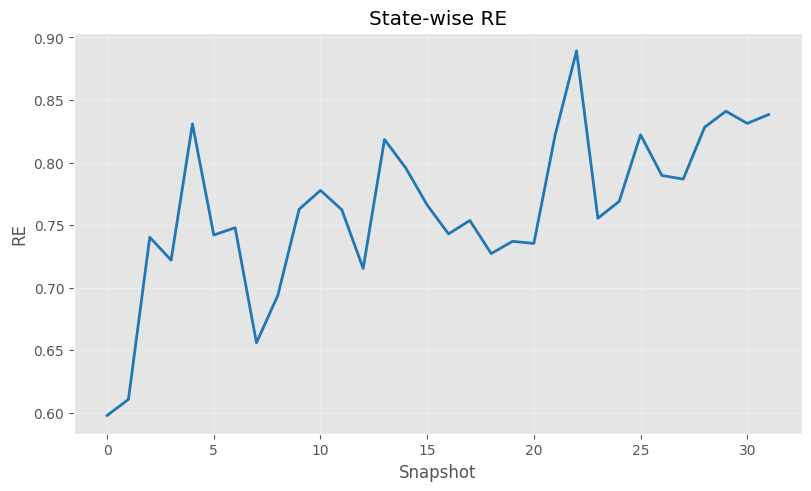

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)

ax.plot(state_errors, linewidth=2, color="tab:blue")
ax.set_title("State-wise RE")
ax.set_xlabel("Snapshot")
ax.set_ylabel("RE")
ax.grid(True, alpha=0.3)

plt.show()
